In [4]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

data = df['Passengers'].values.reshape(-1,1)

In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

In [7]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

seq_length = 1

X, y = create_sequences(data_scaled, seq_length)

In [8]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [10]:
class BasicLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers):
        super(BasicLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [11]:
input_size = 1
hidden_size = 128
num_layers = 3

model = BasicLSTM(input_size, hidden_size, num_layers)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
epochs = 100

for epoch in range(epochs):

    model.train()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/100, Loss: 0.0032
Epoch 2/100, Loss: 0.0033
Epoch 3/100, Loss: 0.0034
Epoch 4/100, Loss: 0.0036
Epoch 5/100, Loss: 0.0037
Epoch 6/100, Loss: 0.0038
Epoch 7/100, Loss: 0.0038
Epoch 8/100, Loss: 0.0038
Epoch 9/100, Loss: 0.0038
Epoch 10/100, Loss: 0.0037
Epoch 11/100, Loss: 0.0037
Epoch 12/100, Loss: 0.0036
Epoch 13/100, Loss: 0.0035
Epoch 14/100, Loss: 0.0034
Epoch 15/100, Loss: 0.0033
Epoch 16/100, Loss: 0.0032
Epoch 17/100, Loss: 0.0032
Epoch 18/100, Loss: 0.0031
Epoch 19/100, Loss: 0.0031
Epoch 20/100, Loss: 0.0031
Epoch 21/100, Loss: 0.0031
Epoch 22/100, Loss: 0.0031
Epoch 23/100, Loss: 0.0031
Epoch 24/100, Loss: 0.0031
Epoch 25/100, Loss: 0.0032
Epoch 26/100, Loss: 0.0032
Epoch 27/100, Loss: 0.0032
Epoch 28/100, Loss: 0.0032
Epoch 29/100, Loss: 0.0032
Epoch 30/100, Loss: 0.0032
Epoch 31/100, Loss: 0.0031
Epoch 32/100, Loss: 0.0031
Epoch 33/100, Loss: 0.0031
Epoch 34/100, Loss: 0.0031
Epoch 35/100, Loss: 0.0031
Epoch 36/100, Loss: 0.0031
Epoch 37/100, Loss: 0.0031
Epoch 38/1

In [17]:
model.eval()

with torch.no_grad():
    train_pred = model(X_train)
    test_pred = model(X_test)

In [18]:
train_pred = scaler.inverse_transform(train_pred.numpy())
test_pred = scaler.inverse_transform(test_pred.numpy())

y_train_actual = scaler.inverse_transform(y_train.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))
print("RMSE:", rmse)

RMSE: 61.36534897389161


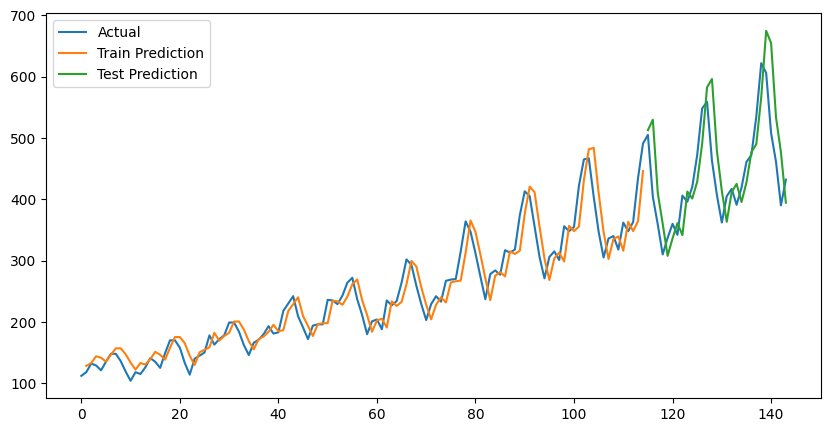

In [19]:
plt.figure(figsize=(10,5))

plt.plot(df['Passengers'].values, label="Actual")

train_plot = np.empty_like(data, dtype=np.float32)
train_plot[:] = np.nan
train_plot[seq_length:train_size+seq_length] = train_pred

test_plot = np.empty_like(data, dtype=np.float32)
test_plot[:] = np.nan
test_plot[train_size+seq_length:] = test_pred

plt.plot(train_plot, label="Train Prediction")
plt.plot(test_plot, label="Test Prediction")

plt.legend()
plt.show()